In [1]:
import pandas as pd
import numpy as np
import random
random.seed(42)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
train_data = pd.read_csv('../data/train_cluster_split0_.csv') # Load training data

In [5]:
train_data

,ab_id,ag_id,label,ag_seq,ab_seq,LCDR1,LCDR2,LCDR3,FRL1,FRL2,...,HCDR3_w2v,LCDR1_w2v,LCDR2_w2v,LCDR3_w2v,FRH1_w2v,FRH2_w2v,FRH3_w2v,FRL1_w2v,FRL2_w2v,FRL3_w2v
0,983,229,1,QLDIVIVLDGSNSIYPWESVIAFLNDLLKRMDIGPKQTQVGIVQYG...,QIQLTQSPSSLSASVGDRVTITCSASSQVNHMFWYQQKPGKAPKPW...,SQVNH,LTS,QQWSGNPWT,QIQLTQSPSSLSASVGDRVTITCSAS,MFWYQQKPGKAPKPWIY,...,"[0.1406835913658142, -0.16077320277690887, 0.3...","[0.5172480344772339, -0.43058955669403076, 0.3...","[-0.24314478039741516, 0.08958751708269119, 0....","[0.04926103726029396, -0.17321482300758362, 0....","[0.23838096857070923, -0.15066194534301758, 0....","[0.10731478780508041, -0.5619941353797913, 0.4...","[0.278400719165802, -0.2659911513328552, 0.605...","[0.4259309768676758, -0.12070192396640778, 0.6...","[0.12102465331554413, -0.22489796578884125, 0....","[0.19907759130001068, -0.25402265787124634, 0...."
1,28,640,1,DSGPIICAGPIHSNKSADIPHLLGYSEKICQIDRLIHVSSWLRNHS...,LTLTQSPATLSVSPGERATLSCRASQSVSSNLAWYQQKPGQAPRLL...,QSVSSN,GAS,QQYNNWPYT,LTLTQSPATLSVSPGERATLSCRAS,LAWYQQKPGQAPRLLIY,...,"[0.16504938900470734, -0.1638532131910324, 0.3...","[0.6938895583152771, -0.4005315601825714, 0.69...","[0.44076743721961975, -0.028017552569508553, 0...","[0.14448733627796173, -0.024454385042190552, 0...","[0.19192419946193695, -0.14669238030910492, 0....","[0.18701042234897614, -0.5353319048881531, 0.5...","[0.24629144370555878, -0.24010935425758362, 0....","[0.41890817880630493, -0.2091500461101532, 0.6...","[0.11544610559940338, -0.25856468081474304, 0....","[0.21846726536750793, -0.2969209551811218, 0.4..."
2,1409,513,1,RPFTLPNLPLSSLSNSRAPLPISSMGISPDNVQSVQFQNGRCTLDG...,EIVMSQSPDSLAVSLGERATINCKSSQSVLYKSDKKNYLAWYQQKS...,QSVLYKSDKKNY,WAS,QQYYSIPRT,EIVMSQSPDSLAVSLGERATINCKSS,LAWYQQKSGQPPKLLIY,...,"[0.23510415852069855, -0.12912121415138245, 0....","[0.28486451506614685, -0.337056964635849, 0.29...","[0.11361774802207947, -0.17487701773643494, 0....","[0.11991123110055923, -0.1309293806552887, 0.5...","[0.2211066484451294, -0.14441172778606415, 0.5...","[0.17911653220653534, -0.6171669363975525, 0.6...","[0.30094003677368164, -0.273135781288147, 0.59...","[0.4170505702495575, -0.08410247415304184, 0.6...","[0.12863391637802124, -0.24194957315921783, 0....","[0.21929295361042023, -0.298063188791275, 0.47..."
3,243,243,1,AKELRCQCIKTYSKPFHPKFIKELRVIESGPHCANTEIIVKLSDGR...,EIVLTQSPATLSLSPGERATLSCRASQSISNNLHWYQQKPGQAPRL...,QSISNN,YTS,GQNNEWPEV,EIVLTQSPATLSLSPGERATLSCRAS,LHWYQQKPGQAPRLLIY,...,"[0.0575358048081398, -0.07747440785169601, 0.4...","[0.5294997096061707, -0.388146311044693, 0.672...","[-0.0651102289557457, -0.8476901054382324, 0.8...","[0.04942286014556885, -0.22075437009334564, 0....","[0.30878618359565735, 0.012646567076444626, 0....","[0.1750561147928238, -0.5491185784339905, 0.42...","[0.27369067072868347, -0.20600269734859467, 0....","[0.35710665583610535, -0.01735394075512886, 0....","[0.19658443331718445, -0.20008817315101624, 0....","[0.21518859267234802, -0.1820105016231537, 0.6..."
4,20,1316,0,MASTTHHHHHHDTDIPTTGGGSRPDDDDKENLYFQGHMSLLPVPYT...,DIVLTQSPGTLSLSPGERATLSCRASQSVISYYVAWYQHKGGQAPR...,QSVISYY,GAS,QYYGSSPLWA,DIVLTQSPGTLSLSPGERATLSCRAS,VAWYQHKGGQAPRLLIY,...,"[0.14935879409313202, -0.18195022642612457, 0....","[0.3221101760864258, -0.3364883065223694, 0.33...","[0.41745665669441223, -0.022466514259576797, 0...","[0.13057146966457367, 0.0010128021240234375, 0...","[0.20660312473773956, -0.15573064982891083, 0....","[0.16703183948993683, -0.6172291040420532, 0.4...","[0.28690940141677856, -0.25908806920051575, 0....","[0.40012872219085693, -0.1325053721666336, 0.6...","[0.12313119322061539, -0.24669820070266724, 0....","[0.2347436547279358, -0.2495773583650589, 0.47..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3392,710,434,0,PQQAPYWTHPQRMEKKLHAVPAGNTVKFRCPAAGNPTPTIRWLKDG...,TGVLSQSVLTQPASVSGSPGQSITISCTGTSSDVGGYKYVSWYQQH...,SSDVGGYKY,EVS,SSYTSSSTWV,QSVLTQPASVSGSPGQSITISCTGT,VSWYQQHPDKAPKLMIY,...,"[0.14748123288154602, -0.09762417525053024, 0...

In [6]:
import ast
train_df = train_data.copy()
train_df['HCDR3_w2v'] = train_df['HCDR3_w2v'].apply(ast.literal_eval)
train_df['LCDR3_w2v'] = train_df['LCDR3_w2v'].apply(ast.literal_eval)
train_df['HCDR2_w2v'] = train_df['HCDR2_w2v'].apply(ast.literal_eval)
train_df['LCDR2_w2v'] = train_df['LCDR2_w2v'].apply(ast.literal_eval)
train_df['HCDR1_w2v'] = train_df['HCDR1_w2v'].apply(ast.literal_eval)
train_df['LCDR1_w2v'] = train_df['LCDR1_w2v'].apply(ast.literal_eval)
train_df['FRH3_w2v'] = train_df['FRH3_w2v'].apply(ast.literal_eval)
train_df['FRL3_w2v'] = train_df['FRL3_w2v'].apply(ast.literal_eval)
train_df['FRH2_w2v'] = train_df['FRH2_w2v'].apply(ast.literal_eval)
train_df['FRL2_w2v'] = train_df['FRL2_w2v'].apply(ast.literal_eval)
train_df['FRH1_w2v'] = train_df['FRH1_w2v'].apply(ast.literal_eval)
train_df['FRL1_w2v'] = train_df['FRL1_w2v'].apply(ast.literal_eval)

In [7]:
train_HCDR3 = np.vstack(train_df["HCDR3_w2v"].values)
train_LCDR3 = np.vstack(train_df["LCDR3_w2v"].values)
train_HCDR2 = np.vstack(train_df["HCDR2_w2v"].values)
train_LCDR2 = np.vstack(train_df["LCDR2_w2v"].values)
train_HCDR1 = np.vstack(train_df["HCDR1_w2v"].values)
train_LCDR1 = np.vstack(train_df["LCDR1_w2v"].values)
train_FRH3 = np.vstack(train_df["FRH3_w2v"].values)
train_FRL3 = np.vstack(train_df["FRL3_w2v"].values)
train_FRH2 = np.vstack(train_df["FRH2_w2v"].values)
train_FRL2 = np.vstack(train_df["FRL2_w2v"].values)
train_FRH1 = np.vstack(train_df["FRH1_w2v"].values)
train_FRL1 = np.vstack(train_df["FRL1_w2v"].values)

In [8]:
Train_fea = np.concatenate([train_HCDR3, train_LCDR3, train_HCDR2, train_LCDR2, train_HCDR1, train_LCDR1,
                            train_FRH3, train_FRL3, train_FRH2, train_FRL2, train_FRH1, train_FRL1], axis=1)

In [9]:
Train_fea

array([[ 0.14068359, -0.1607732 ,  0.3516047 , ..., -0.30167094,
        -0.34438851,  0.07679445],
       [ 0.16504939, -0.16385321,  0.39310557, ..., -0.26668063,
        -0.38424683,  0.10046411],
       [ 0.23510416, -0.12912121,  0.47593439, ..., -0.30227873,
        -0.31111613,  0.11962821],
       ...,
       [ 0.09136853, -0.07136063,  0.36087677, ..., -0.26517963,
        -0.32113242,  0.08620656],
       [ 0.17675275, -0.16465217,  0.33856022, ..., -0.24063946,
        -0.32117924,  0.08654352],
       [ 0.17874305, -0.08778511,  0.37461501, ..., -0.25852653,
        -0.28190786,  0.08798656]])

In [10]:
# Shuffle dataset to eliminate batch effect
features = Train_fea
labels = np.array(list(train_df['label'].values))

In [9]:
from autogluon.tabular import TabularPredictor
import os

# ========= 4️⃣ 转换为 DataFrame =========
label_col = 'label'

def to_df(X, y=None):
    cols = [f'f{i}' for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=cols)
    if y is not None:
        df[label_col] = y
    return df

train_df = to_df(features, labels)
# test_df = to_df(X_test)   # ❗测试集不要标签

# ========= 5️⃣ 设置模型保存路径 =========
outdir = "../Auto_model/AutoGluon_w2v64_split0_/"
os.makedirs(outdir, exist_ok=True)

# ========= 6️⃣ 训练模型 =========
predictor = TabularPredictor(
    label=label_col,
    path=outdir,
    problem_type='binary',
    eval_metric='roc_auc'
).fit(
    train_data=train_df,
    num_bag_folds=10,
    num_bag_sets=1,
    presets='best_quality',
    verbosity=2
)

# ========= 7️⃣ 预测 =========
# y_pred = predictor.predict(test_df)
# y_prob = predictor.predict_proba(test_df)[1]  # 正类概率
#
# # ========= 8️⃣ 简单评估 =========
# from sklearn.metrics import roc_auc_score
#
# auc = roc_auc_score(y_test, y_prob)
# print("Test ROC-AUC:", auc)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.8.17
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #149~20.04.1-Ubuntu SMP Wed Apr 16 08:29:56 UTC 2025
CPU Count:          20
Memory Avail:       58.76 GB / 62.60 GB (93.9%)
Disk Space Avail:   282.23 GB / 1832.70 GB (15.4%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=10, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdout validation data is used to detect s

In [10]:
test_data = pd.read_csv('../data/test_cluster_split0_.csv') # Load test data

In [11]:
import ast
test_df = test_data.copy()
test_df['HCDR3_w2v'] = test_df['HCDR3_w2v'].apply(ast.literal_eval)
test_df['LCDR3_w2v'] = test_df['LCDR3_w2v'].apply(ast.literal_eval)
test_df['HCDR2_w2v'] = test_df['HCDR2_w2v'].apply(ast.literal_eval)
test_df['LCDR2_w2v'] = test_df['LCDR2_w2v'].apply(ast.literal_eval)
test_df['HCDR1_w2v'] = test_df['HCDR1_w2v'].apply(ast.literal_eval)
test_df['LCDR1_w2v'] = test_df['LCDR1_w2v'].apply(ast.literal_eval)
test_df['FRH3_w2v'] = test_df['FRH3_w2v'].apply(ast.literal_eval)
test_df['FRL3_w2v'] = test_df['FRL3_w2v'].apply(ast.literal_eval)
test_df['FRH2_w2v'] = test_df['FRH2_w2v'].apply(ast.literal_eval)
test_df['FRL2_w2v'] = test_df['FRL2_w2v'].apply(ast.literal_eval)
test_df['FRH1_w2v'] = test_df['FRH1_w2v'].apply(ast.literal_eval)
test_df['FRL1_w2v'] = test_df['FRL1_w2v'].apply(ast.literal_eval)

In [12]:
test_HCDR3 = np.vstack(test_df["HCDR3_w2v"].values)
test_LCDR3 = np.vstack(test_df["LCDR3_w2v"].values)
test_HCDR2 = np.vstack(test_df["HCDR2_w2v"].values)
test_LCDR2 = np.vstack(test_df["LCDR2_w2v"].values)
test_HCDR1 = np.vstack(test_df["HCDR1_w2v"].values)
test_LCDR1 = np.vstack(test_df["LCDR1_w2v"].values)
test_FRH3 = np.vstack(test_df["FRH3_w2v"].values)
test_FRL3 = np.vstack(test_df["FRL3_w2v"].values)
test_FRH2 = np.vstack(test_df["FRH2_w2v"].values)
test_FRL2 = np.vstack(test_df["FRL2_w2v"].values)
test_FRH1 = np.vstack(test_df["FRH1_w2v"].values)
test_FRL1 = np.vstack(test_df["FRL1_w2v"].values)

In [13]:
Test_fea = np.concatenate([test_HCDR3, test_LCDR3, test_HCDR2, test_LCDR2, test_HCDR1, test_LCDR1,
                           test_FRH3, test_FRL3, test_FRH2, test_FRL2, test_FRH1, test_FRL1], axis=1)

In [14]:
labels_test = np.array(list(test_df['label'].values))

In [15]:
from autogluon.tabular import TabularPredictor
predictor = TabularPredictor.load("../data/Auto_model/AutoGluon_w2v64_split0_/") # Load the trained model

In [16]:
def to_df(X, y=None):
    cols = [f'f{i}' for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=cols)
    if y is not None:
        df[label_col] = y
    return df

In [17]:
test_df = to_df(Test_fea)

In [18]:
y_pred = predictor.predict(test_df)
y_prob = predictor.predict_proba(test_df)[1]

In [19]:
from sklearn.metrics import roc_auc_score, average_precision_score

auc = roc_auc_score(labels_test, y_prob)   # ROC AUC
aupr = average_precision_score(labels_test, y_prob)  # AUPR

print("AUC =", auc)
print("AUPR =", aupr)

AUC = 0.878596866096866
AUPR = 0.895524375808834


In [12]:
import ast
from autogluon.tabular import TabularPredictor
from sklearn.metrics import roc_auc_score, average_precision_score
from collections import Counter
from sklearn.metrics import roc_auc_score, roc_curve
import pandas as pd
import numpy as np

In [14]:
def to_df(X, y=None):
    cols = [f'f{i}' for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=cols)
    if y is not None:
        df[label_col] = y
    return df

In [15]:
auc_list = []
all_tts_aucs = []
all_tts_permy_aucs = []
all_tts_fprs = []
all_tts_tprs = []
all_tts_permy_fprs = []
all_tts_permy_tprs = []

In [16]:
for seed in range(5):
    test_data = pd.read_csv(f'../data/test_cluster_split{seed}_.csv')


    test_df = test_data.copy()
    test_df['HCDR3_w2v'] = test_df['HCDR3_w2v'].apply(ast.literal_eval)
    test_df['LCDR3_w2v'] = test_df['LCDR3_w2v'].apply(ast.literal_eval)
    test_df['HCDR2_w2v'] = test_df['HCDR2_w2v'].apply(ast.literal_eval)
    test_df['LCDR2_w2v'] = test_df['LCDR2_w2v'].apply(ast.literal_eval)
    test_df['HCDR1_w2v'] = test_df['HCDR1_w2v'].apply(ast.literal_eval)
    test_df['LCDR1_w2v'] = test_df['LCDR1_w2v'].apply(ast.literal_eval)
    test_df['FRH3_w2v'] = test_df['FRH3_w2v'].apply(ast.literal_eval)
    test_df['FRL3_w2v'] = test_df['FRL3_w2v'].apply(ast.literal_eval)
    test_df['FRH2_w2v'] = test_df['FRH2_w2v'].apply(ast.literal_eval)
    test_df['FRL2_w2v'] = test_df['FRL2_w2v'].apply(ast.literal_eval)
    test_df['FRH1_w2v'] = test_df['FRH1_w2v'].apply(ast.literal_eval)
    test_df['FRL1_w2v'] = test_df['FRL1_w2v'].apply(ast.literal_eval)

    test_HCDR3 = np.vstack(test_df["HCDR3_w2v"].values)
    test_LCDR3 = np.vstack(test_df["LCDR3_w2v"].values)
    test_HCDR2 = np.vstack(test_df["HCDR2_w2v"].values)
    test_LCDR2 = np.vstack(test_df["LCDR2_w2v"].values)
    test_HCDR1 = np.vstack(test_df["HCDR1_w2v"].values)
    test_LCDR1 = np.vstack(test_df["LCDR1_w2v"].values)
    test_FRH3 = np.vstack(test_df["FRH3_w2v"].values)
    test_FRL3 = np.vstack(test_df["FRL3_w2v"].values)
    test_FRH2 = np.vstack(test_df["FRH2_w2v"].values)
    test_FRL2 = np.vstack(test_df["FRL2_w2v"].values)
    test_FRH1 = np.vstack(test_df["FRH1_w2v"].values)
    test_FRL1 = np.vstack(test_df["FRL1_w2v"].values)


    Test_fea = np.concatenate([test_HCDR3, test_LCDR3, test_HCDR2, test_LCDR2, test_HCDR1, test_LCDR1,
                           test_FRH3, test_FRL3, test_FRH2, test_FRL2, test_FRH1, test_FRL1], axis=1)

    labels_test = np.array(list(test_df['label'].values))
    labels_test_perm = np.random.binomial(n=1, p=(Counter(labels_test)[1.0]/len(labels_test)), size=[len(labels_test)]) # random ys



    predictor = TabularPredictor.load(f"../Auto_model/AutoGluon_w2v64_split{seed}_")

    test_df = to_df(Test_fea)

    y_pred = predictor.predict(test_df)
    y_prob = predictor.predict_proba(test_df)[1]

    # ===================== 计算真实标签指标 =====================
    auc = roc_auc_score(labels_test, y_prob)
    fpr, tpr, _ = roc_curve(labels_test, y_prob)

    # ===================== 计算随机标签指标 =====================
    auc_perm = roc_auc_score(labels_test_perm, y_prob)
    fpr_perm, tpr_perm, _ = roc_curve(labels_test_perm, y_prob)

    # ===================== 存入列表 =====================
    all_tts_aucs.append(auc)
    all_tts_permy_aucs.append(auc_perm)
    all_tts_fprs.append(fpr)
    all_tts_tprs.append(tpr)
    all_tts_permy_fprs.append(fpr_perm)
    all_tts_permy_tprs.append(tpr_perm)

    # ===================== 打印本次结果 =====================
    print(f"seed {seed} | AUC = {auc:.4f} | Perm AUC = {auc_perm:.4f}")

# ===================== 最终输出 =====================
print("\n===== 5次实验全部完成 =====")
print(f"平均AUC: {np.mean(all_tts_aucs):.4f} ± {np.std(all_tts_aucs, ddof=1):.4f}")
print(f"平均随机AUC: {np.mean(all_tts_permy_aucs):.4f}")

seed 0 | AUC = 0.9011 | Perm AUC = 0.4897
seed 1 | AUC = 0.8933 | Perm AUC = 0.4651
seed 2 | AUC = 0.8936 | Perm AUC = 0.5258
seed 3 | AUC = 0.8895 | Perm AUC = 0.4938
seed 4 | AUC = 0.8877 | Perm AUC = 0.4932

===== 5次实验全部完成 =====
平均AUC: 0.8930 ± 0.0052
平均随机AUC: 0.4935


In [17]:
scv_df = pd.DataFrame(columns=['AUCs','PermYAUCs','TPRs','FPRs','FPRperms','TPRperms'])
scv_df['AUCs'] = all_tts_aucs
scv_df['PermYAUCs'] = all_tts_permy_aucs

scv_df['FPRs'] = all_tts_fprs
scv_df['TPRs'] = all_tts_tprs
scv_df['FPRperms'] = all_tts_permy_fprs
scv_df['TPRperms'] = all_tts_permy_tprs

In [18]:
scv_df

,AUCs,PermYAUCs,TPRs,FPRs,FPRperms,TPRperms
0,0.901135,0.489742,"[0.0, 0.005319148936170213, 0.5585106382978723, 0.5585106382978723, 0.6170212765957447, 0.6170212765957447, 0.6436170212765957, 0.6436170212765957, 0.6542553191489362, 0.6542553191489362, 0.6595744680851063, 0.6595744680851063, 0.6702127659574468, 0.6702127659574468, 0.6861702127659575, 0.6861702127659575, 0.6914893617021277, 0.6914893617021277, 0.6968085106382979, 0.6968085106382979, 0.7127659574468085, 0.7127659574468085, 0.7180851063829787, 0.7180851063829787, 0.723404255319149, 0.723404255319149, 0.7340425531914894, 0.7340425531914894, 0.7393617021276596, 0.7393617021276596, 0.74468085...","[0.0, 0.0, 0.0, 0.0035335689045936395, 0.0035335689045936395, 0.014134275618374558, 0.014134275618374558, 0.02120141342756184, 0.02120141342756184, 0.028268551236749116, 0.028268551236749116, 0.0353356890459364, 0.0353356890459364, 0.038869257950530034, 0.038869257950530034, 0.05653710247349823, 0.05653710247349823, 0.06713780918727916, 0.06713780918727916, 0.0706713780918728, 0.0706713780918728, 0.07420494699646643, 0.07420494699646643, 0.07773851590106007, 0.07773851590106007, 0.08833922261484099, 0.08833922261484099, 0.0989399293286219, 0.0989399293286219, 0.10954063604240283, 0.1095406...","[0.0, 0.0, 0.010238907849829351, 0.010238907849829351, 0.013651877133105802, 0.013651877133105802, 0.027303754266211604, 0.027303754266211604, 0.030716723549488054, 0.030716723549488054, 0.03754266211604096, 0.03754266211604096, 0.05802047781569966, 0.05802047781569966, 0.06143344709897611, 0.06143344709897611, 0.09215017064846416, 0.09215017064846416, 0.10921501706484642, 0.10921501706484642, 0.11945392491467577, 0.11945392491467577, 0.12286689419795221, 0.12286689419795221, 0.12627986348122866, 0.12627986348122866, 0.1296928327645051, 0.1296928327645051, 0.13993174061433447, 0.1399317406...","[0.0, 0.0056179775280898875, 0.0056179775280898875, 0.011235955056179775, 0.011235955056179775, 0.02247191011235955, 0.02247191011235955, 0.03932584269662921, 0.03932584269662921, 0.056179775280898875, 0.056179775280898875, 0.07303370786516854, 0.07303370786516854, 0.07865168539325842, 0.07865168539325842, 0.08426966292134831, 0.08426966292134831, 0.09550561797752809, 0.09550561797752809, 0.10112359550561797, 0.10112359550561797, 0.11235955056179775, 0.11235955056179775, 0.11797752808988764, 0.11797752808988764, 0.12921348314606743, 0.12921348314606743, 0.1348314606741573, 0.13483146067415..."
1,0.893289,0.465109,"[0.0, 0.004629629629629629, 0.6388888888888888, 0.6388888888888888, 0.6481481481481481, 0.6481481481481481, 0.6527777777777778, 0.6527777777777778, 0.6574074074074074, 0.6574074074074074, 0.6620370370370371, 0.6620370370370371, 0.6666666666666666, 0.6666666666666666, 0.6712962962962963, 0.6712962962962963, 0.6759259259259259, 0.6759259259259259, 0.6851851851851852, 0.6851851851851852, 0.6944444444444444, 0.6944444444444444, 0.6990740740740741, 0.6990740740740741, 0.7175925925925926, 0.7175925925925926, 0.7222222222222222, 0.7222222222222222, 0.7268518518518519, 0.7268518518518519, 0.731481...","[0.0, 0.0, 0.0, 0.003816793893129771, 0.003816793893129771, 0.007633587786259542, 0.007633587786259542, 0.011450381679389313, 0.011450381679389313, 0.015267175572519083, 0.015267175572519083, 0.019083969465648856, 0.019083969465648856, 0.03435114503816794, 0.03435114503816794, 0.04198473282442748, 0.04198473282442748, 0.04580152671755725, 0.04580152671755725, 0.05725190839694656, 0.05725190839694656, 0.0648854961832061, 0.0648854961832061, 0.06870229007633588, 0.06870229007633588, 0.07251908396946564, 0.07251908396946564, 0.07633587786259542, 0.07633587786259542, 0.08396946564885496, 0.083...","[0.0, 0.004016064257028112, 0.004016064257028112, 0.012048192771084338, 0.012048192771084338, 0.01606425702811245, 0.01606425702811245, 0.028112449799196786, 0.028112449799196786, 0.0321285140562249, 0.0321285140562249, 0.04417670682730924, 0.04417670682730924, 0.05220883534136546, 0.05220883534136546,

In [25]:
scv_df.to_pickle('../data/sabdab_results.pkl') # Save the predicted results

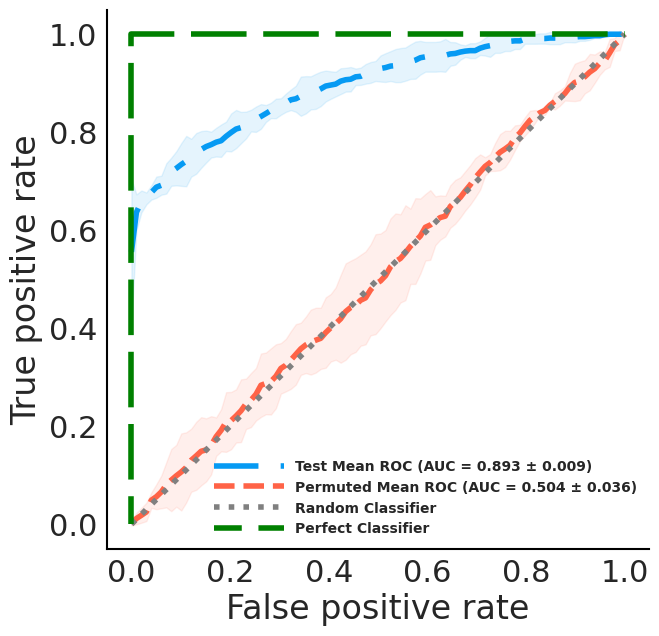

In [4]:
# Load pickle from example OR change to your SCV results
scv_df = pd.read_pickle('../data/sabdab_results.pkl')

val_fpr = scv_df.FPRs.values
val_tpr = scv_df.TPRs.values
fpr_perm = scv_df.FPRperms.values
tpr_perm = scv_df.TPRperms.values
mean_auc = np.mean(scv_df.AUCs.values)
std_auc = np.std(scv_df.AUCs.values)
mean_auc_perm = np.mean(scv_df.PermYAUCs.values)
std_auc_perm = np.std(scv_df.PermYAUCs.values)

# Define a common set of FPR values
common_fpr = np.linspace(0, 1, 100)
common_fpr_perm = np.linspace(0, 1, 100)

interp_tpr = []
interp_tpr_perm = []

# Interpolate TPR values for each fold
for i in range(len(val_fpr)):
    interp_tpr.append(np.interp(common_fpr, val_fpr[i], val_tpr[i]))
    interp_tpr_perm.append(np.interp(common_fpr_perm, fpr_perm[i], tpr_perm[i]))

# Calculate the mean and standard deviation of the interpolated TPR values
mean_tpr = np.mean(interp_tpr, axis=0)
std_tpr = np.std(interp_tpr, axis=0)
mean_tpr_perm = np.mean(interp_tpr_perm, axis=0)
std_tpr_perm = np.std(interp_tpr_perm, axis=0)

# Create the plot
fig = plt.figure(figsize =(7, 7)) #
plt.grid(False)        # 关闭网格
plt.gca().set_facecolor('white')  # 设置背景为白色
plt.plot(common_fpr, mean_tpr, color='#069AF3', label='Test Mean ROC (AUC = %0.3f \u00B1 %0.3f)' % (mean_auc, 2*std_auc), linewidth = 4, dashes=[8, 4, 2, 4, 2, 4])
plt.fill_between(common_fpr, (mean_tpr - 2*std_tpr), (mean_tpr + 2*std_tpr), color='#069AF3', alpha=0.1)
plt.plot(common_fpr_perm, mean_tpr_perm, color='tomato', label='Permuted Mean ROC (AUC = %0.3f \u00B1 %0.3f)' % (mean_auc_perm, 2*std_auc_perm), linewidth = 4, linestyle='--')
plt.fill_between(common_fpr_perm, (mean_tpr_perm - 2*std_tpr_perm), (mean_tpr_perm + 2*std_tpr_perm), color='tomato', alpha=0.1)

# Customize the plot
plt.plot([0, 1], [0, 1], linestyle=':', color='gray', linewidth=4, label='Random Classifier')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.plot([0, 0, 1], [0, 1, 1], linestyle=(5, (10, 3)), color='green', linewidth = 4, label='Perfect Classifier')
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

# plt.title('Standard Cross Validation MutInt Mixed Model Example', fontweight='bold', fontsize=24)
plt.xlabel('False positive rate', fontsize=24)
plt.ylabel('True positive rate', fontsize=24)
plt.legend(loc="lower right", prop={'size': 12, 'weight':'bold'}, handlelength=5)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.gca().spines['bottom'].set_visible(True)
plt.gca().spines['left'].set_visible(True)
plt.gca().spines['bottom'].set_linewidth(1.5)
plt.gca().spines['left'].set_linewidth(1.5)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')

plt.legend(
    loc="lower right",
    prop={'size': 10, 'weight': 'bold'}, # 12
    handlelength=5,
    frameon=False  # 这一行就是去掉图例框的关键！
)

plt.savefig('.../data/sabdab_results.jpg', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()